In [9]:
import sqlite3
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from analysis import data, compute


ROOT = Path.cwd()

BLUE, ORANGE, GREEN, RED, MUTED = "#2a78d6", "#eb6834", "#0ca30c", "#d03b3b", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "figure.dpi": 110,
})
pd.set_option("display.max_columns", 10)

In [10]:
stations = data.stations()
print(f"{len(stations)} stations in the database")
stations.head(8)

14 stations in the database


,id,name
0,116,Cerrillos I
1,149,Quilicura I
2,190,Pudahuel (Acreditada)
3,197,Talagante
4,228,Cerro Navia
5,233,Puente Alto
6,239,Las Condes (Acreditada)
7,260,El Bosque (Acreditada)


In [11]:
import re


STATION_ID = "273"
page = urllib.request.urlopen(
    f"https://sinca.mma.gob.cl/index.php/estacion/index/id/{STATION_ID}",
    timeout=30,
).read().decode("utf-8", "replace")

links = re.findall(
    r"macropath=([^&]+)&amp;macro=([^&]+)&amp;from=(\d{6})&amp;to=(\d{6})", page
)
print(f"{len(links)} dataset links found on the station page, e.g.:")
for macropath, macro, frm, to in links[:4]:
    print(f"    {macropath:<22} {macro:<20} {frm}..{to}")


30 dataset links found on the station page, e.g.:
    ./RM/D14/Cal/0001      0001.diario.diario   970719..170108
    ./RM/D14/Cal/0001      0001.horario.horario 970718..170109
    ./RM/D14/Cal/0002      0002.diario.diario   090326..260817
    ./RM/D14/Cal/0002      0002.horario.horario 090325..260818


In [12]:
url = (
    "https://sinca.mma.gob.cl/cgi-bin/APUB-MMA/apub.tsindico2.cgi"
    "?outtype=xcl&macro=./RM/D14/Cal/PM25//PM25.diario.diario.ic"
    "&from=250101&to=250107&path=/usr/airviro/data/CONAMA/&lang=esp"
)
raw = urllib.request.urlopen(url, timeout=30).read().decode("utf-8")
print(raw)

FECHA (YYMMDD);HORA (HHMM);Registros validados;Registros preliminares;Registros no validados;
250101;0000;11;;;
250102;0000;9;;;
250103;0000;13;;;
250104;0000;12;;;
250105;0000;12;;;
250106;0000;11;;;



In [13]:
import sinca


rows = list(sinca.fetch_series(
    "./RM/D14/Cal/PM25", "PM25.diario.diario", "2024-01-01", "2024-01-10"
))
pd.DataFrame(rows)

,date,time,validated,preliminary,unvalidated
0,2024-01-01,00:00,8.0,None,None
1,2024-01-02,00:00,13.0,None,None
2,2024-01-03,00:00,16.0,None,None
3,2024-01-04,00:00,17.0,None,None
4,2024-01-05,00:00,12.0,None,None
5,2024-01-06,00:00,11.0,None,None
6,2024-01-07,00:00,7.0,None,None
7,2024-01-08,00:00,9.0,None,None
8,2024-01-09,00:00,9.0,None,None


In [14]:
with data.connect() as db:
    schema = pd.read_sql_query(
        "SELECT name, type FROM sqlite_master WHERE type='table'", db
    )
    counts = pd.read_sql_query(
        """
        SELECT
            (SELECT COUNT(*) FROM stations) AS stations,
            (SELECT COUNT(*) FROM series) AS series,
            (SELECT COUNT(*) FROM measurements) AS measurements
        """,
        db,
    )
print(schema.to_string(index=False))
counts

           name  type
       stations table
         series table
sqlite_sequence table
   measurements table


,stations,series,measurements
0,14,138,5587252


In [33]:
with data.connect() as db:
    tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table'"
            , db
        )["name"]

    all_cols = pd.concat(
        [pd.read_sql_query(f"PRAGMA table_info('{t}')", db).assign(table=t)
        for t in tables],
        ignore_index=True
    )

all_cols

,cid,name,type,notnull,dflt_value,pk,table
0,0,id,INTEGER,0,None,1,stations
1,1,name,TEXT,1,None,0,stations
2,2,region,TEXT,1,None,0,stations
3,0,id,INTEGER,0,None,1,series
4,1,station_id,INTEGER,1,None,0,series
5,2,code,TEXT,1,None,0,series
6,3,name,TEXT,0,None,0,series
7,4,kind,TEXT,1,None,0,series
8,5,freq,TEXT,1,None,0,series
9,6,macropath,TEXT,1,None,0,series


In [ ]:
with data.connect() as db:
    per_station = pd.read_sql_query(
        """
        SELECT st.name AS station, COUNT(*) AS rows,
            MIN(m.ts) AS first, MAX(m.ts) AS last
        FROM measurements m
        JOIN series s ON s.id = m.series_id
        JOIN stations st ON st.id = s.station_id
        GROUP BY st.id ORDER BY rows DESC
        """,
        db
    )
per_station

,station,rows,first,last
0,Parque O'Higgins,644032,1997-04-02 00:00,2026-07-17 11:00
1,La Florida (Acreditada),637509,1997-04-07 00:00,2026-07-17 11:00
2,Pudahuel (Acreditada),631261,1997-04-04 00:00,2026-07-17 11:00
3,El Bosque (Acreditada),606130,1997-04-02 00:00,2026-07-17 11:00
4,Las Condes (Acreditada),601718,1997-04-02 00:00,2026-07-17 11:00
5,Independencia,503990,1997-04-02 00:00,2021-08-02 02:00
6,Cerro Navia,496965,2001-03-24 00:00,2026-07-17 11:00
7,Puente Alto,456664,2008-05-21 00:00,2026-07-17 11:00
8,Talagante,412805,2008-05-26 00:00,2026-07-17 11:00
9,Cerrillos I,375240,1997-04-02 00:00,2017-01-12 10:00


In [ ]:
import sklearn


for mod in (pd, np, sklearn):
    print(f"{mod.__name__:<12} {mod.__version__}")

pandas       3.0.5
numpy        2.5.2
sklearn      1.9.0


In [ ]:
raw_wind = data.daily_weather("WSPD")
print("Wind speed (m/s), BEFORE cleaning:")
print(raw_wind["wspd"].describe())
print()
print("The two offending rows (1st and 2nd):")
raw_wind.sort_values("wspd", ascending=False).head(5)

Wind speed (m/s), BEFORE cleaning:
count    7.045300e+04
mean     1.445336e+18
std      2.859432e+20
min      0.000000e+00
25%      8.422394e-01
50%      1.163022e+00
75%      1.557885e+00
max      6.788550e+22
Name: wspd, dtype: float64

The two offending rows (1st and 2nd):


,station_id,station,date,wspd
55278,262,La Florida (Acreditada),2024-03-27,6.788550e+22
55277,262,La Florida (Acreditada),2024-03-26,3.394275e+22
69765,273,Parque O'Higgins,2024-08-27,1.250000e+01
69764,273,Parque O'Higgins,2024-08-26,1.250000e+01
37744,239,Las Condes (Acreditada),2016-11-18,7.361411e+00


In [34]:
df = data.station_daily_table("PM25")
print()
print("Wind speed (m/s), AFTER cleaning:")
print(df["wspd"].describe())

data QC: dropped 485 rows with sensor-fault readings

Wind speed (m/s), AFTER cleaning:
count    63409.000000
mean         1.251126
std          0.622787
min          0.000000
25%          0.828230
50%          1.138887
75%          1.523934
max          7.361411
Name: wspd, dtype: float64


In [39]:
df.isnull().sum()

station_id        0
station           0
date              0
value             0
temp          14166
rhum          14497
wspd          13685
dtype: int64

Region-wide trend: -0.440 µg/m³ per year (p = 0.0000)


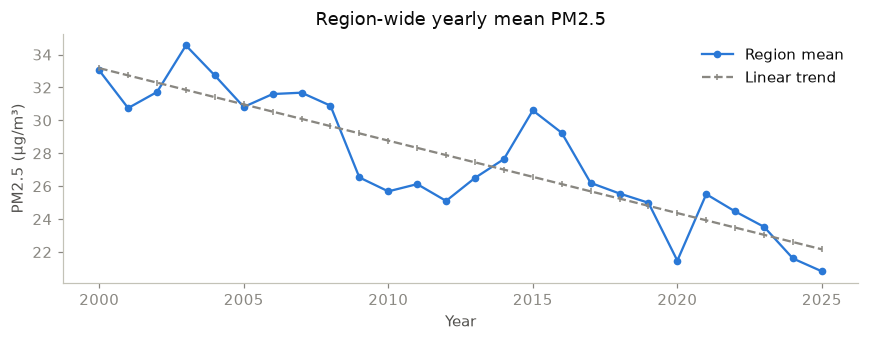

In [110]:
trends = compute.trends_and_seasonality(df)

stations_t =list(trends["by_station"].values())
all_years = sorted({y for s in stations_t for y in s["years"]})

region_mean = [
    np.mean([s["mean"][s["years"].index(yr)] for s in stations_t if yr in s["years"]])
    for yr in all_years
]

slope, intercept, r, p, se = stats.linregress(all_years, region_mean)
print(f"Region-wide trend: {slope:+.3f} µg/m³ per year (p = {p:.4f})")

linear_trend = [intercept + slope * y for y in all_years]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(all_years, region_mean, color=BLUE, marker="o", ms=4, label="Region mean")
ax.plot(all_years, linear_trend, color=MUTED, marker="|", ms=4, ls="--", label="Linear trend")
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Region-wide yearly mean PM2.5")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
sig_stations = sorted(stations_t, key=lambda s: s["slope_per_year"])

print(f"{'Station':<28} {'slope (µg/m³/yr)':>18} {'p-value':>10}    significant?")
for s in sig_stations:
    sig = "yes" if s["p_value"] < 0.05 else "no"
    print(f"{s['name']:<28} {s['slope_per_year']:>18.3f} {s['p_value']:>10.4f}    {sig}")




Station                        slope (µg/m³/yr)    p-value    significant?
Quilicura                                -0.840     0.0033    yes
Parque O'Higgins                         -0.663     0.0000    yes
La Florida (Acreditada)                  -0.552     0.0000    yes
El Bosque (Acreditada)                   -0.472     0.0229    yes
Cerro Navia                              -0.374     0.0028    yes
Las Condes (Acreditada)                  -0.369     0.0000    yes
Pudahuel (Acreditada)                    -0.361     0.0001    yes
Puente Alto                              -0.327     0.0498    yes
Cerrillos I                              -0.299     0.6254    no
Independencia                            -0.180     0.4251    no
Quilicura I                               0.015     0.9690    no
Talagante                                 0.121     0.5213    no
